(512, 512, 614)


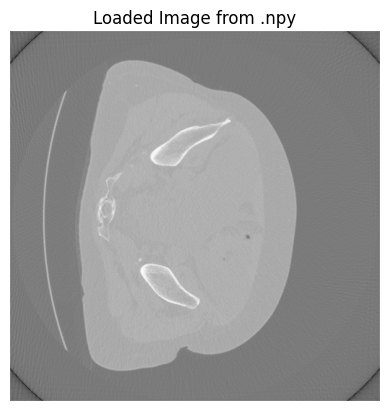

In [6]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

# 1. 加载 .nii 文件
def load_nii(file_path):
    """
    加载 .nii 文件并返回图像数据和 affine 矩阵
    """
    nii_image = nib.load(file_path)
    data = nii_image.get_fdata()  # 获取图像数据
    affine = nii_image.affine  # 获取 affine 矩阵
    return data, affine

# 2. 定义参数
input_nii_path = r"C:\Users\kuer\Documents\GitHub\wr-3d\output\reconstruction_angle_360.0_image.nii" # 输入的 .nii 文件路径

# 3. 加载 .nii 文件
data, affine = load_nii(input_nii_path)

# 4. 检查数据维度
if data.ndim != 3:
    raise ValueError("Input data must be 3D (slices, rows, columns).")

print(data.shape)  # 输出数据维度

# 5. 创建交互式可视化
def plot_slice(ax, slice_idx):
    """
    显示指定切片的图像
    """
    ax.clear()
    ax.imshow(data[slice_idx, :, :], cmap='gray')
    ax.set_title(f'Slice {slice_idx}')
    ax.axis('off')

# 6. 设置初始切片
# # 3. 显示图像
plt.imshow(data[:,:,200], cmap='gray')  # 如果是灰度图像，使用 cmap='gray'
plt.title("Loaded Image from .npy")  # 设置标题
plt.axis('off')  # 关闭坐标轴
plt.show()

In [11]:
def grey_scale(img_gray ):
    rows, cols = img_gray.shape
    flat_gray = img_gray.reshape((cols * rows,)).tolist()
    A = min(flat_gray)
    B = max(flat_gray)
    print('A = %d,B = %d' % (A, B))
    output = np.uint8(255 / (B - A) * (img_gray - A) + 0.5)
    return output




float32
(512, 512)
131.0
-174.0


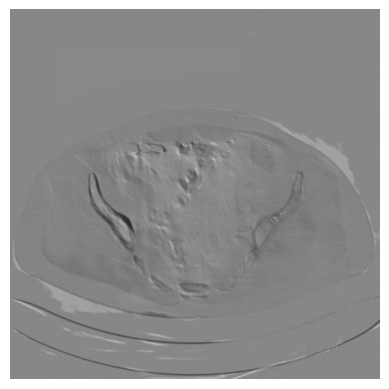

In [102]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
# a='GT'
# a='FDK'
# a='bmenet'
# a='fbpconvnet'
# a='SIRT3D'
a='transunet'
# 读取两幅图像
image1_ = cv2.imread(rf"C:\Users\kuer\Documents\GitHub\wr-3d\output_dir_90\{a}\output_0400.png")
image2_ = cv2.imread(r"C:\Users\kuer\Documents\GitHub\wr-3d\output_dir\GT\output_0400.png")
image1 = cv2.cvtColor(image1_, cv2.COLOR_RGB2GRAY).astype(np.float32)
image2 = cv2.cvtColor(image2_, cv2.COLOR_RGB2GRAY).astype(np.float32)
print(image1.dtype)
print(image2.shape)
# plt.imshow(image1, cmap='gray')
# plt.show()

# 计算差值
# difference = cv2.absdiff(image1, image2)
difference = image1 - image2
print(np.max(difference))
print(np.min(difference))
plt.plot()
plt.imshow(difference, cmap='gray',vmin=-255, vmax=255)
plt.axis('off')
plt.savefig(rf'C:\Users\kuer\Documents\毕设\figure\difference\400\{a}',bbox_inches='tight', pad_inches = -0.1) 
plt.show()

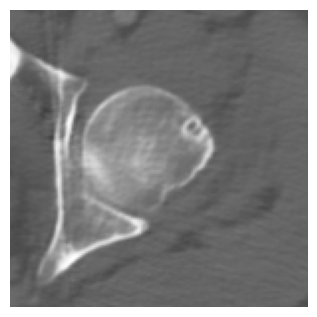

In [129]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# a='FDK'
# a='GT'
# a='bmenet_40'
a='fbpconvnet'
# a='SIRT3D'
# a='transunet'
# 读取图像
image = mpimg.imread(rf"C:\Users\kuer\Documents\GitHub\wr-3d\output_dir\{a}\output_0480.png")


# 显示原始图像
# plt.figure(figsize=(10, 5))
# plt.subplot(1, 2, 1)
# plt.title('Original Image')
# plt.imshow(image)

# 定义ROI区域（例如，从图像中提取一个矩形区域）
# 假设我们想要从图像中提取从 (100, 100) 到 (300, 300) 的区域
roi = image[200:350, 300:450]

# 显示ROI区域
plt.subplot(1, 2, 2)
plt.imshow(roi)
plt.axis('off')
plt.savefig(rf'C:\Users\kuer\Documents\毕设\figure\roi\480\{a}',bbox_inches='tight', pad_inches = -0.1) 
# 调整布局并显示图像
plt.tight_layout()
plt.show()

1050.0
-450.0
1.0
0.0


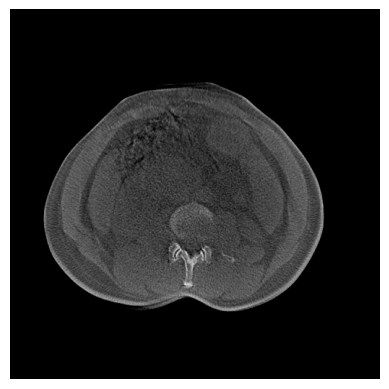

In [148]:
import numpy as np
import matplotlib.pyplot as plt
import pydicom

def apply_window(image, window_width, window_level):
    """
    调整 CT 图像的窗宽和窗位
    :param image: 输入的 CT 图像（NumPy 数组）
    :param window_width: 窗宽
    :param window_level: 窗位
    :return: 调整后的图像
    """
    # 计算窗宽范围
    window_min = window_level - window_width / 2
    window_max = window_level + window_width / 2

    # 将像素值限制在窗宽范围内
    windowed_image = np.clip(image, window_min, window_max)
    print(np.max(windowed_image))
    print(np.min(windowed_image))

    windowed_image = (windowed_image - window_min) / window_width
    print(np.max(windowed_image))
    print(np.min(windowed_image))
    return windowed_image

# 设置窗宽和窗位
window_width = 1500  # 窗宽
window_level = 300   # 窗位

data=pydicom.dcmread(r"C:\Users\kuer\Documents\GitHub\noise2sim-master\dataset\1.2.156.147522.44.410947.12.3.330.20250106161218.dcm").pixel_array
# 应用窗宽和窗位调整
windowed_image = apply_window(data, window_width, window_level)
roi = windowed_image[200:400, 100:300]
plt.imshow(windowed_image, cmap='gray')
# plt.show()
# plt.imshow(roi, cmap='gray')
plt.axis('off')
plt.savefig(r'C:\Users\kuer\Desktop\n2n\330', bbox_inches='tight', pad_inches=0.0, dpi=300)
plt.show()



In [ ]:
import numpy as np
import pydicom
import os
import re

def load_dicom(dicom_dir):
    """
    加载 DICOM 文件并返回图像数据和元数据
    """
    if not os.path.exists(dicom_dir):
        raise FileNotFoundError(f"DICOM directory {dicom_dir} not found.")

    dicom_files = [os.path.join(dicom_dir, f) for f in os.listdir(dicom_dir) if f.endswith('.dcm')or f.endswith('.IMA')]
    dicom_files.sort(key=lambda x: int(re.search(r'\d{2}(?=\D*$)',os.path.basename(x)).group()) if re.search(r'\d{2}(?=\D*$)', os.path.basename(x)) else 0)
    slices = [pydicom.dcmread(f) for f in dicom_files]

    # 获取像素数据
    data = [s.pixel_array for s in slices]
    # 将列表转换为 NumPy 数组
    data = np.stack(data, axis=0)  # 沿第 0 轴堆叠，形成 3D 数组

    return data

# RAW 文件路径
raw_file_path = r"C:\Users\kuer\Documents\GitHub\wr-3d\simulated_dataset\train\gt"

data = load_dicom(raw_file_path) 
print(data.shape)

(3411, 512, 512)


In [160]:
import os
import pydicom
import numpy as np
from pydicom.uid import generate_uid
from pydicom.dataset import FileDataset
from pydicom import Dataset

def merge_dicom_series(input_dir, output_dir, merge_factor=5):
    # 创建输出目录
    os.makedirs(output_dir, exist_ok=True)

    # 读取并排序DICOM文件（按InstanceNumber）
    files = [f for f in os.listdir(input_dir) if f.endswith('.dcm')]
    datasets = [pydicom.dcmread(os.path.join(input_dir, f)) for f in files]
    datasets.sort(key=lambda ds: ds.InstanceNumber)

    # 初始化新系列参数
    new_series_uid = generate_uid()
    series_time = generate_uid()[6:]  # 生成近似时间字符串

    # 提取所有切片的像素数据
    pixel_arrays = [ds.pixel_array.astype(np.float32) for ds in datasets]

    # 合并薄层图像为厚层图像
    num_slices = len(pixel_arrays)
    new_num_slices = num_slices // merge_factor
    merged_pixel_data = []

    for i in range(new_num_slices):
        start_slice = i * merge_factor
        end_slice = start_slice + merge_factor
        slices_to_merge = pixel_arrays[start_slice:end_slice]
        merged_slice = np.mean(slices_to_merge, axis=0).astype(np.uint16)  # 计算平均值并转换为16位整数
        merged_pixel_data.append(merged_slice)

    # 保存合并后的DICOM系列
    for idx, array in enumerate(merged_pixel_data):
        # 创建新数据集
        file_meta = Dataset()
        file_meta.MediaStorageSOPClassUID = datasets[0].SOPClassUID
        file_meta.MediaStorageSOPInstanceUID = generate_uid()
        file_meta.TransferSyntaxUID = pydicom.uid.ExplicitVRLittleEndian
        # print(datasets[0].SamplesPerPixel)
        # break
        # 创建新的FileDataset对象
        new_ds = FileDataset(f"merged_image_{idx:04d}.dcm", {}, file_meta=file_meta, preamble=b"\0" * 128)

        # 设置数据集的基本信息
        new_ds.Modality = datasets[0].Modality
        new_ds.PatientName = datasets[0].PatientName
        new_ds.PatientID = datasets[0].PatientID
        new_ds.StudyInstanceUID = datasets[0].StudyInstanceUID
        new_ds.SeriesInstanceUID = new_series_uid
        new_ds.ContentDate = datasets[0].ContentDate
        new_ds.ContentTime = series_time
        new_ds.StudyDate = datasets[0].StudyDate
        new_ds.StudyTime = datasets[0].StudyTime
        new_ds.AccessionNumber = datasets[0].AccessionNumber
        new_ds.ReferringPhysicianName = datasets[0].ReferringPhysicianName
        new_ds.Manufacturer = datasets[0].Manufacturer
        new_ds.InstitutionName = datasets[0].InstitutionName
        new_ds.StationName = datasets[0].StationName if hasattr(datasets[0], 'StationName') else ''
        new_ds.InstanceNumber = idx + 1
        new_ds.SeriesNumber = 2  # 新的系列编号
        new_ds.SeriesDescription = "Merged CT Series"
        new_ds.SOPInstanceUID = file_meta.MediaStorageSOPInstanceUID
        new_ds.SOPClassUID = datasets[0].SOPClassUID
        new_ds.SliceThickness = datasets[0].SliceThickness * merge_factor/2
        new_ds.PixelSpacing = datasets[0].PixelSpacing
        new_ds.ImagePositionPatient = datasets[0].ImagePositionPatient[:2] + [datasets[0].ImagePositionPatient[2] - idx * datasets[0].SliceThickness * merge_factor/2]
        new_ds.ImageOrientationPatient = datasets[0].ImageOrientationPatient
        new_ds.SamplesPerPixel = datasets[0].SamplesPerPixel
        new_ds.PhotometricInterpretation = datasets[0].PhotometricInterpretation
        new_ds.Rows = array.shape[0]
        new_ds.Columns = array.shape[1]
        new_ds.BitsStored = datasets[0].BitsStored
        new_ds.BitsAllocated = datasets[0].BitsAllocated
        new_ds.HighBit = datasets[0].HighBit
        new_ds.PixelRepresentation = datasets[0].PixelRepresentation

        # 更新像素数据
        new_ds.PixelData = array.tobytes()

        # 保存文件
        output_path = os.path.join(output_dir, f"merged_image_{idx:04d}.dcm")
        new_ds.save_as(output_path)

    print(f"合并后的厚层图像已保存到 {output_dir}")

# 示例用法
merge_dicom_series(r"D:\安健科技重大专项项目\安健科技重大专项项目\0110人体数据集\0000013\RAW_1K\WR_FullSpine\ImageReconstruction\1.2.156.147522.44.410947.13.1.1.20241118170918\1.2.156.147522.44.410947.13.5.20250108175021", r"C:\Users\kuer\Desktop\merged_slices", merge_factor=2)



c:\Users\kuer\miniconda3\envs\ct\Lib\site-packages\pydicom\valuerep.py:440: UserWarning: Invalid value for VR TM: '6.0.1.3680043.8.498.24771064138521599203093646886976466323'.
  warn_and_log(msg)
c:\Users\kuer\miniconda3\envs\ct\Lib\site-packages\pydicom\valuerep.py:440: UserWarning: The value length (18) exceeds the maximum length of 16 allowed for VR SH.
  warn_and_log(msg)
c:\Users\kuer\miniconda3\envs\ct\Lib\site-packages\pydicom\valuerep.py:440: UserWarning: The value length (17) exceeds the maximum length of 16 allowed for VR SH.
  warn_and_log(msg)
c:\Users\kuer\miniconda3\envs\ct\Lib\site-packages\pydicom\charset.py:541: UserWarning: Failed to encode value with encodings: iso8859 - using replacement characters in encoded string
  warn_and_log(


合并后的厚层图像已保存到 C:\Users\kuer\Desktop\merged_slices


1000
-1273


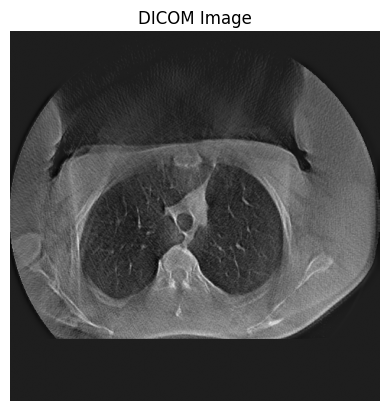

In [5]:
import pydicom
import matplotlib.pyplot as plt
import numpy as np
# 读取DICOM文件
dicom_file = pydicom.dcmread(r"C:\Users\kuer\Documents\GitHub\wr-3d\wr3d_dataset\train\gt\1.2.156.147522.44.410947.12.3.71.20250108165917.dcm")

# 获取像素数据
pixel_array = dicom_file.pixel_array
print(np.max(pixel_array))
print(np.min(pixel_array))

# 展示图像
plt.imshow(pixel_array, cmap='gray')
plt.title('DICOM Image')
plt.axis('off')  # 不显示坐标轴
plt.show()